# 035 激活初始化与信号传播

请清空内核并从头运行。先看懂两样本手算，再进行48配置尺度/激活扫描。全部是合成CPU实验，不提供现实泛化结论。

In [1]:
from pathlib import Path
import sys, csv, json, math, hashlib, tempfile, unittest
import numpy as np
import torch
from IPython.display import display, Image
BASE = Path.cwd()
if not (BASE / 'experiment.py').exists():
    BASE = BASE / 'units' / '035'
if not (BASE / 'experiment.py').exists():
    raise RuntimeError('请从035单元目录或课程仓库根启动Notebook')
sys.path.insert(0, str(BASE))
import experiment as e
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
print({'python':sys.version.split()[0], 'torch':torch.__version__, 'numpy':np.__version__, 'device':'cpu'})

{'python': '3.12.14', 'torch': '2.7.1+cpu', 'numpy': '2.3.5', 'device': 'cpu'}


## 1 冻结数据和统计轴
CSV的128行是训练数据。逐列中心化不意味着所有隐藏层在当前数据上的均值为0。

In [2]:
x, y = e.load_data()
print('shape:', x.shape, y.shape)
print('first 2 rows (first 3 features and target):', np.c_[x[:2,:3],y[:2]])
print('max absolute feature mean:', np.abs(x.mean(0)).max())
print('input pooled second moment:', np.mean(x*x))

shape: (128, 16) (128, 1)
first 2 rows (first 3 features and target): [[-1.13498858  0.83457805  1.2930683  -0.72632012]
 [-0.81585252  0.69195205  1.07901795 -0.50184398]]
max absolute feature mean: 5.4643789493269423e-17
input pooled second moment: 1.0


## 2 精确手算闭环
下列Fraction来自独立标量循环。请对照正文逐个中间值，不要把程序输出当作省略手算的理由。

In [3]:
hand = e.hand_reference()
for row in hand['before']:
    print({k: [float(t) for t in v] if isinstance(v,list) else float(v) for k,v in row.items()})
print('all 13 gradients:', [float(t) for t in hand['gradient']])
print('updated parameters:', [float(t) for t in hand['updated']])
print('loss:',hand['loss'],'new loss:',float(hand['new_loss']))
for row in hand['after']:
    print('new forward:', {k: [float(t) for t in v] if isinstance(v,list) else float(v) for k,v in row.items()})

{'x': 1.0, 'y': 0.5, 'z1': [1.2, -0.9], 'h1': [1.2, 0.0], 'z2': [0.7, 0.5], 'h2': [0.7, 0.5], 'pred': 0.55, 'residual': 0.05, 'e': 0.025, 'dh2': [0.025, -0.0125], 'dz2': [0.025, -0.0125], 'dh1': [0.009375, -0.0125], 'dz1': [0.009375, 0.0]}
{'x': -1.0, 'y': -0.5, 'z1': [-0.8, 1.1], 'h1': [0.0, 1.1], 'z2': [-0.175, 0.75], 'h2': [0.0, 0.75], 'pred': -0.275, 'residual': 0.225, 'e': 0.1125, 'dh2': [0.1125, -0.05625], 'dz2': [0.0, -0.05625], 'dh1': [-0.0140625, -0.028125], 'dz1': [0.0, -0.028125]}
all 13 gradients: [0.009375, 0.028125, 0.009375, -0.028125, 0.03, 0.0, -0.015, -0.061875, 0.025, -0.06875, 0.0175, 0.096875, 0.1375]
updated parameters: [0.9990625, -1.0028125, 0.1990625, 0.1028125, 0.497, -0.25, 0.2515, 0.5061875, 0.0975, 0.206875, 0.99825, -0.5096875, 0.08625]
loss: 17/1280 new loss: 0.009650990940541462
new forward: {'x': 1.0, 'y': 0.5, 'z1': [1.198125, -0.9], 'h1': [1.198125, 0.0], 'z2': [0.692968125, 0.5082034375], 'h2': [0.692968125, 0.5082034375], 'pred': 0.5189804912304687,

## 3 独立梯度和有限差分
步长不能跨ReLU门边界。主例全部13坐标远离边界，才适合此检查。

In [4]:
theta=np.array([float(t) for t in hand['theta']]); loss,g=e.hand_torch(theta)
reference=np.array([float(t) for t in hand['gradient']])
fd=[]
for j in range(13):
    left=theta.copy();right=theta.copy();left[j]-=1e-6;right[j]+=1e-6
    fd.append((e.hand_torch(right)[0]-e.hand_torch(left)[0])/2e-6)
print('max autodiff vs Fraction error:',float(np.max(np.abs(g-reference))))
print('max autodiff vs central difference error:',float(np.max(np.abs(g-fd))))
np.testing.assert_allclose(g,reference,atol=2e-16,rtol=0)
np.testing.assert_allclose(g,fd,atol=4e-11,rtol=0)

max autodiff vs Fraction error: 5.551115123125783e-17
max autodiff vs central difference error: 4.728287206212656e-12


## 4 完整重跑并核对数值文件
这里确实重新训练48个配置，不读取已保存结果后冒充重新执行。临时目录在格结束后移除；5个SHA-256必须与发布参考逐一一致。不同软件版本可能产生浮点差异，须调查后记录，不能静默跳过。

分布文件使用无损gzip（level9、mtime=0、空文件名），保留全部原JSON字节；同时核对解压后的长度与SHA-256。压缩字节一致限于记录的运行环境，不宣称跨压缩器版本一致。

In [5]:
filenames=['results.json','selected_distributions.json.gz','layer_statistics.csv','training_curves.csv','width_study.csv']
with tempfile.TemporaryDirectory(prefix='dl035-') as tmp:
    rerun=e.run(Path(tmp),steps=100)
    comparisons={name:hashlib.sha256((Path(tmp)/name).read_bytes()).hexdigest()==hashlib.sha256((BASE/'outputs'/name).read_bytes()).hexdigest() for name in filenames}
    print(comparisons)
    if not all(comparisons.values()):
        raise RuntimeError('重跑摘要与参考不同，请检查协议及环境版本')
import gzip
raw = gzip.decompress((BASE/'outputs/selected_distributions.json.gz').read_bytes())
if len(raw) != 23870931 or hashlib.sha256(raw).hexdigest() != '14aa21584fc6fd57f1b38b84e11aba100c67c0f22b30c7fd7625460c9ac6cd10':
    raise RuntimeError('解压后分布内容与完整原始JSON不同')
with gzip.open(BASE/'outputs/selected_distributions.json.gz','rt',encoding='utf-8') as stream:
    distributions=json.load(stream)
print('distribution groups:',len(distributions),'raw JSON bytes:',len(raw))
print('recomputed cases:',len(rerun['cases']))

{'results.json': True, 'selected_distributions.json.gz': True, 'layer_statistics.csv': True, 'training_curves.csv': True, 'width_study.csv': True}


distribution groups: 12 raw JSON bytes: 23870931
recomputed cases: 48


## 5 二阶矩 中心方差与均值
用CSV各层数据核查恒等式。统计轴是128×64池化位置，不是8192个独立实验。

In [6]:
with (BASE/'outputs/layer_statistics.csv').open() as f:
    stats=list(csv.DictReader(f))
err=max(abs(float(r['h_second'])-float(r['h_variance'])-float(r['h_mean'])**2) for r in stats)
axis_err=max(abs(float(r['h_variance'])-float(r['mean_unit_data_variance'])-float(r['variance_unit_data_means'])) for r in stats)
print('layer rows:',len(stats),'maximum moment residual:',err,'axis residual:',axis_err)
print(rerun['mechanisms']['relu_moments'])

layer rows: 576 maximum moment residual: 9.094947017729282e-13 axis residual: 1.862645149230957e-09
{'z': {'mean': 0.0, 'variance': 0.9974445577355454, 'second': 0.9974445577355454, 'q01': -2.326286822656969, 'q50': 0.0, 'q99': 2.32628682265697, 'zero_fraction': 0.0}, 'relu': {'mean': 0.39850178508195067, 'variance': 0.33991860615427155, 'second': 0.4987222788677727, 'q01': 0.0, 'q50': 9.954796177614919e-06, 'q99': 2.32628682265697, 'zero_fraction': 0.5}, 'gaussian_prediction_mean': 0.39843221735161105, 'gaussian_prediction_variance': np.float64(0.3399740470440512)}


## 6 前向深度曲线
实线是3种子中位数，范围带不是置信区间；点线仅在linear/ReLU下使用已推导的总体递推。

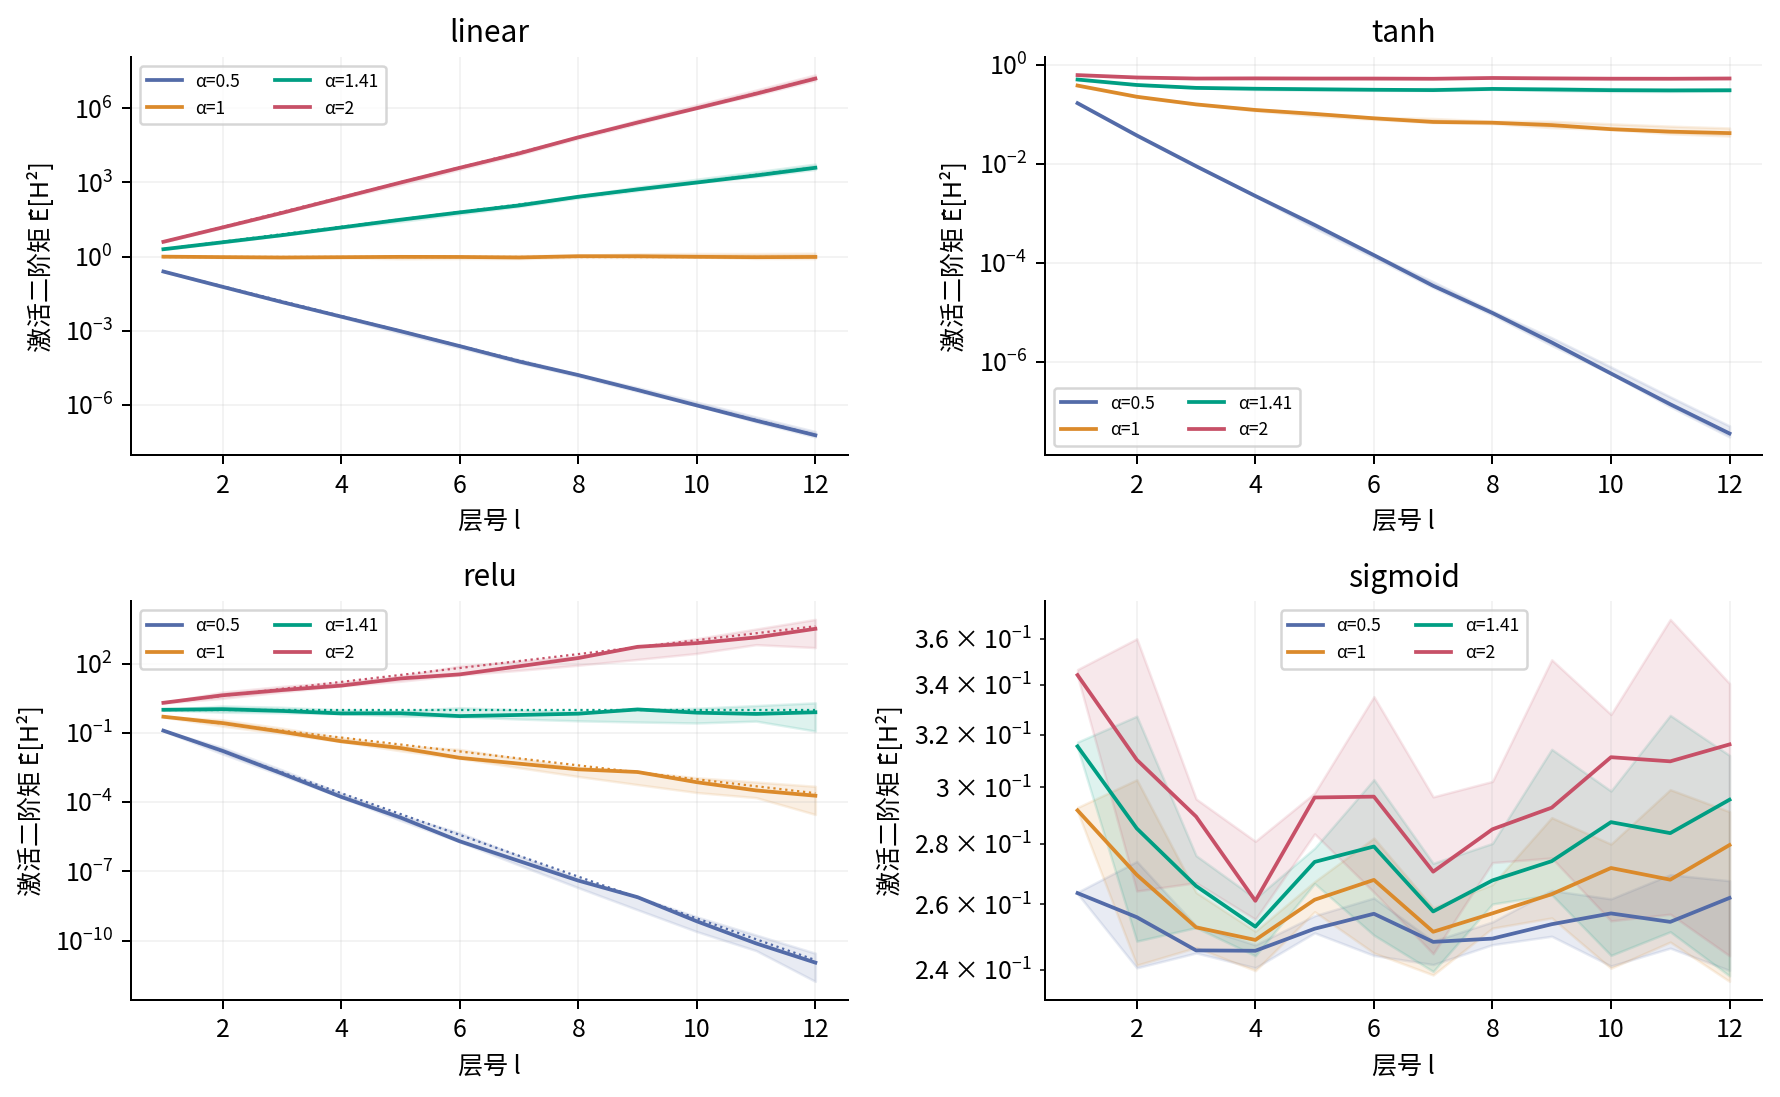

ReLU alpha, median layer12 second: 0.5 1.1323886284058514e-11
ReLU alpha, median layer12 second: 1.0 0.00018998328614708705
ReLU alpha, median layer12 second: 1.4142135623730951 0.7781715400584697
ReLU alpha, median layer12 second: 2.0 3187.390628079487


In [7]:
display(Image(filename=str(BASE/'figures/06_forward_depth.png')))
for alpha in e.SCALES:
    values=[float(r['h_second']) for r in stats if r['activation']=='relu' and float(r['alpha'])==alpha and int(r['layer'])==12]
    print('ReLU alpha, median layer12 second:',alpha,float(np.median(values)))

## 7 反向探针与实际任务梯度
Q是独立终端探针的标量，不是half-MSE。相对尺度图不能替代原始任务梯度分布。

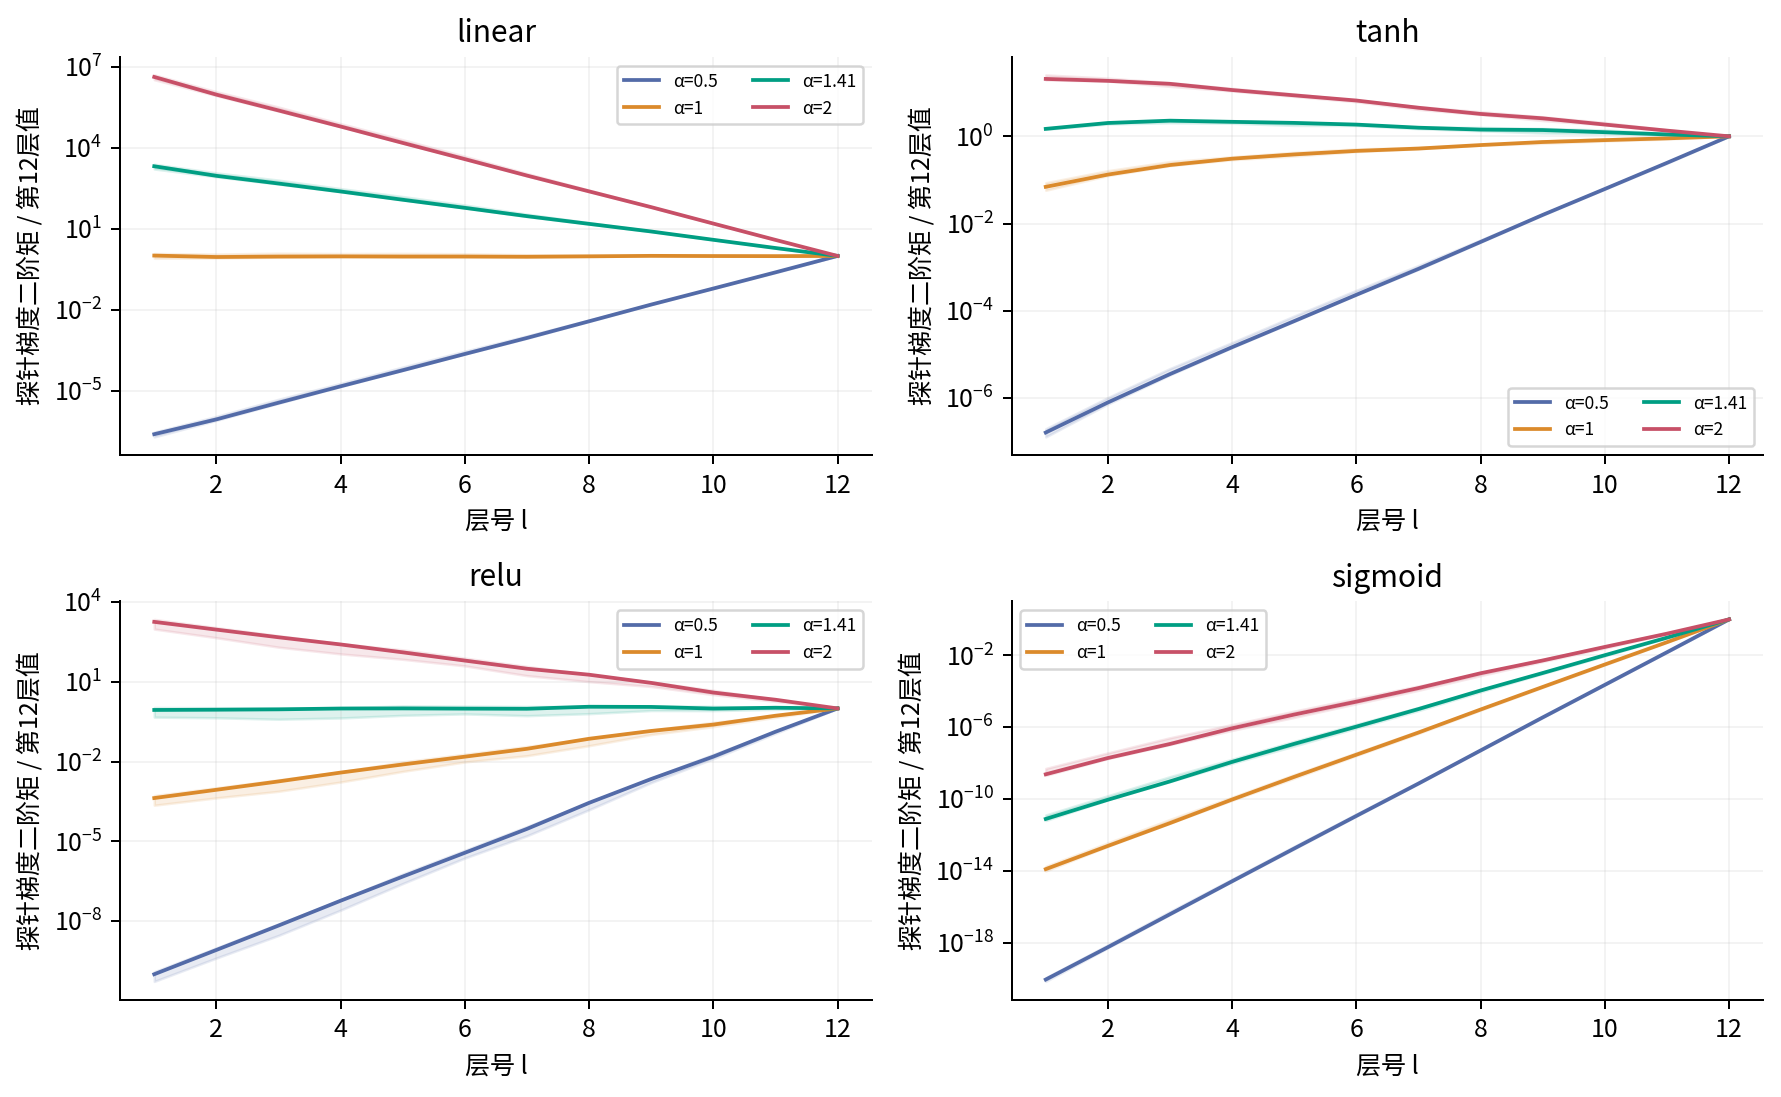

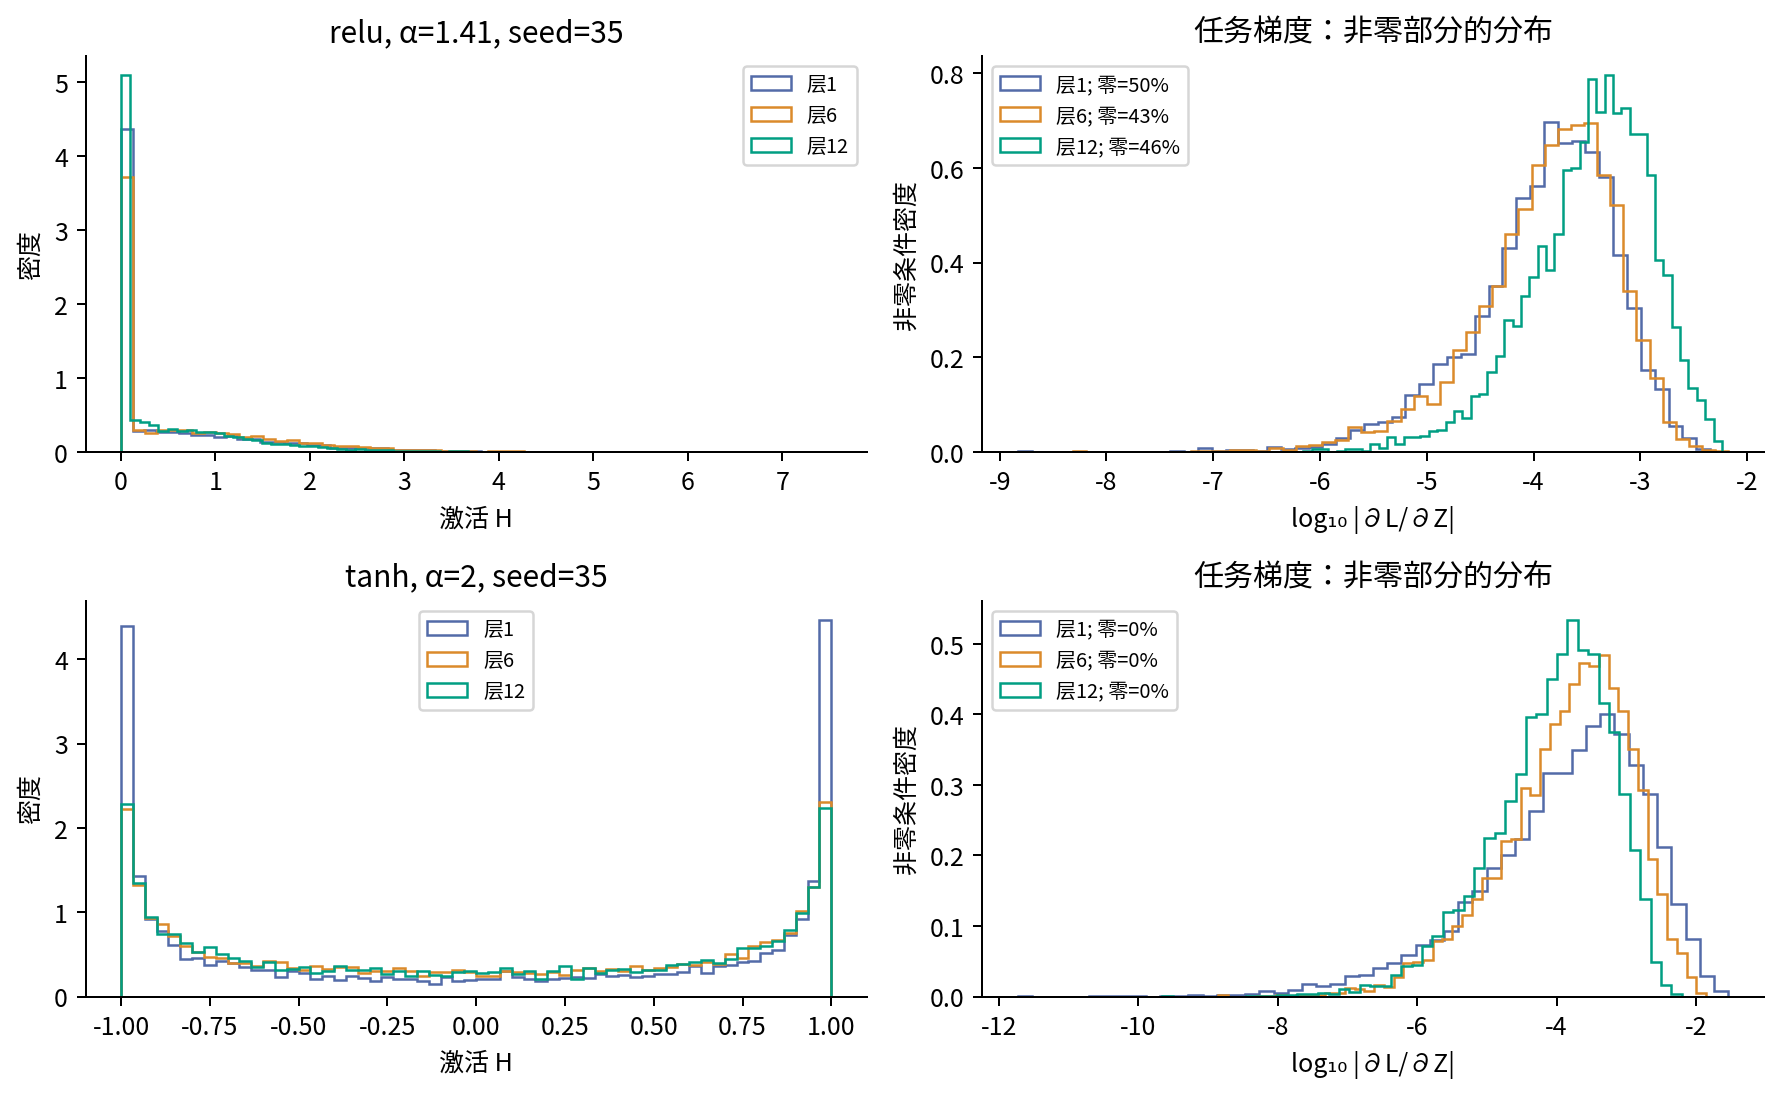

linear probe layer1/layer12: 0.818172529022993
tanh probe layer1/layer12: 0.057897067012795025
relu probe layer1/layer12: 0.00023008347925616209
sigmoid probe layer1/layer12: 1.0038992213073098e-14


In [8]:
display(Image(filename=str(BASE/'figures/07_backward_depth.png')))
display(Image(filename=str(BASE/'figures/08_distributions.png')))
for act in e.ACTS:
    rows=[r for r in stats if r['activation']==act and float(r['alpha'])==1. and int(r['seed'])==35]
    print(act,'probe layer1/layer12:',float(rows[0]['probe_grad_second'])/float(rows[-1]['probe_grad_second']))

## 8 训练曲线与停止记录
不要延长失败曲线，也不要只对幸存种子做排行榜。

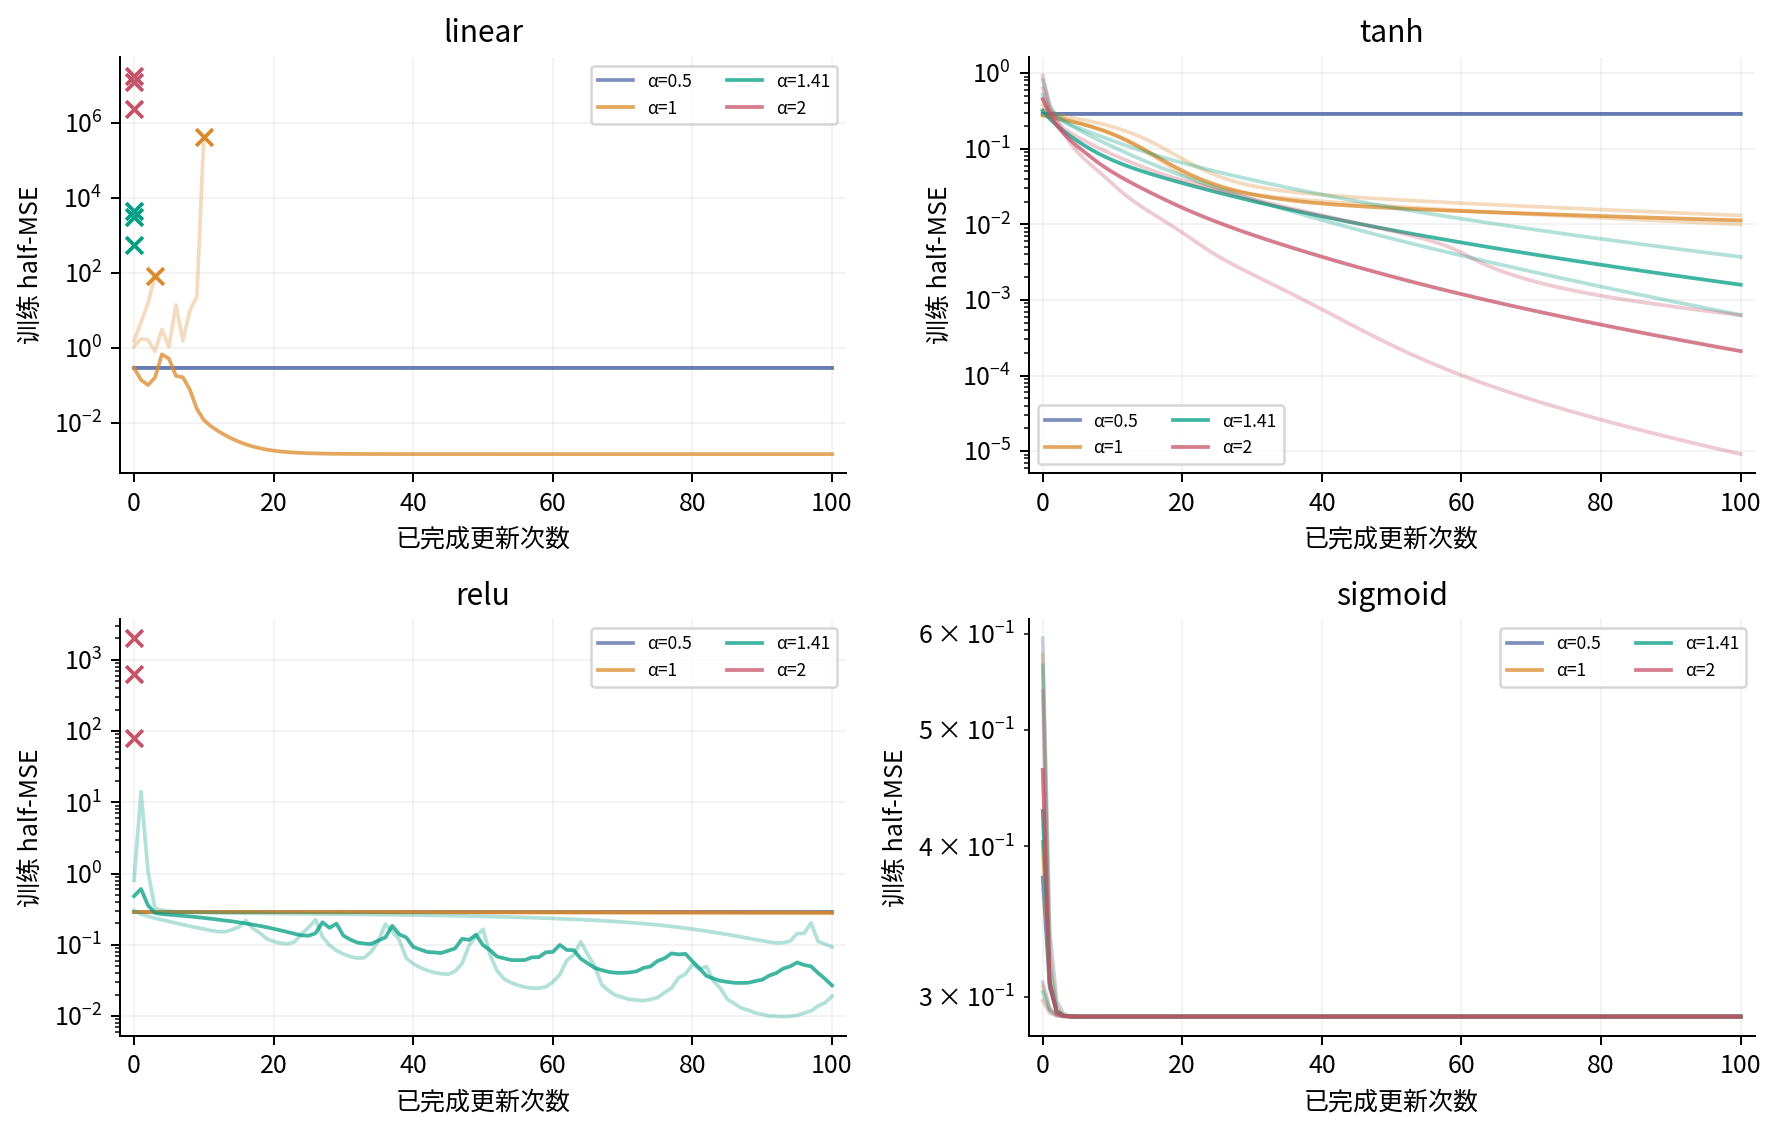

Counter({'completed': 37, 'stopped_loss_limit': 11})
{'activation': 'linear', 'alpha': 1.0, 'seed': 36, 'status': 'stopped_loss_limit', 'updates_applied': 4, 'last_recorded_loss': 81.49006617368957}
{'activation': 'linear', 'alpha': 1.0, 'seed': 37, 'status': 'stopped_loss_limit', 'updates_applied': 11, 'last_recorded_loss': 419817.9871939995}
{'activation': 'linear', 'alpha': 1.4142135623730951, 'seed': 35, 'status': 'stopped_loss_limit', 'updates_applied': 1, 'last_recorded_loss': 546.3393831283171}
{'activation': 'linear', 'alpha': 1.4142135623730951, 'seed': 36, 'status': 'stopped_loss_limit', 'updates_applied': 1, 'last_recorded_loss': 4379.452968304209}
{'activation': 'linear', 'alpha': 1.4142135623730951, 'seed': 37, 'status': 'stopped_loss_limit', 'updates_applied': 1, 'last_recorded_loss': 3000.8900044901284}
{'activation': 'linear', 'alpha': 2.0, 'seed': 35, 'status': 'stopped_loss_limit', 'updates_applied': 1, 'last_recorded_loss': 2271293.474849573}
{'activation': 'linear',

In [9]:
display(Image(filename=str(BASE/'figures/09_training_curves.png')))
from collections import Counter
print(Counter(c['status'] for c in rerun['cases']))
for c in rerun['cases']:
    if c['status']!='completed':
        print({k:c[k] for k in ['activation','alpha','seed','status','updates_applied','last_recorded_loss']})

## 9 有限宽和统计轴
宽度实验每档16个初始化种子，与主扫描的3种子不同。

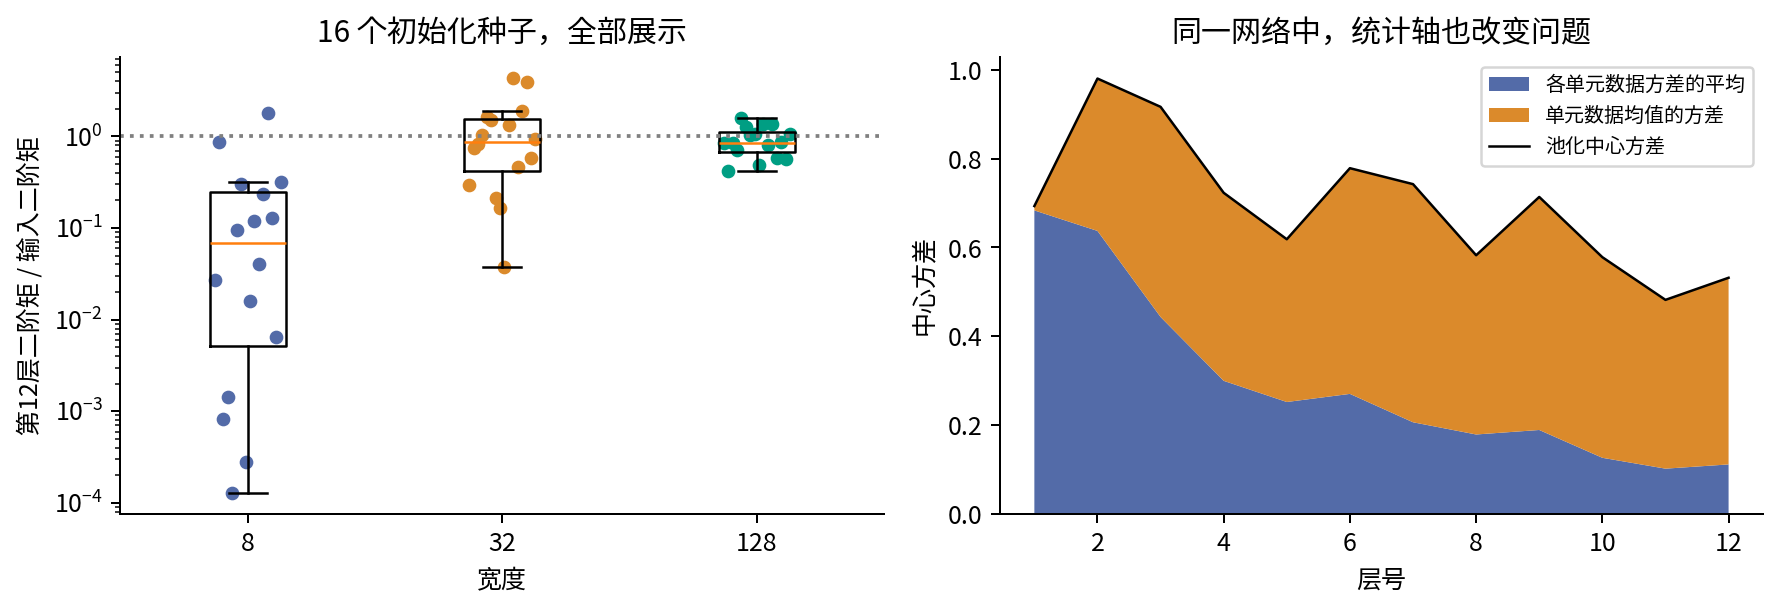

8 min/median/max: 0.00012906727047659624 0.06791532796200334 1.7998057504204974
32 min/median/max: 0.037356314905942475 0.8779347555596132 4.380632658637592
128 min/median/max: 0.4197057415155109 0.8543083672073368 1.5727756314633665


In [10]:
display(Image(filename=str(BASE/'figures/10_width_and_axes.png')))
with (BASE/'outputs/width_study.csv').open() as f:
    widths=list(csv.DictReader(f))
for w in (8,32,128):
    vals=[float(r['last_second_over_input']) for r in widths if int(r['width'])==w]
    print(w,'min/median/max:',np.min(vals),np.median(vals),np.max(vals))

## 10 哪些独立拆分不成立
这些反例是有限精确计算，不是假设所有实际网络必然以同样方式偏离。

{'actual_variance': 1.9999999999999996, 'diagonal_only': 0.9999999999999998, 'full_covariance': 1.9999999999999996}
{'joint_second': 0.5, 'product_of_seconds': 0.25, 'relu_at_zero': 0.0, 'central_difference_at_zero': 0.5}
{'balanced': [1.0, 1.0], 'rank_deficient': [1.4142135623730951, 0.0], 'mean_square_singular_values': 1.0}


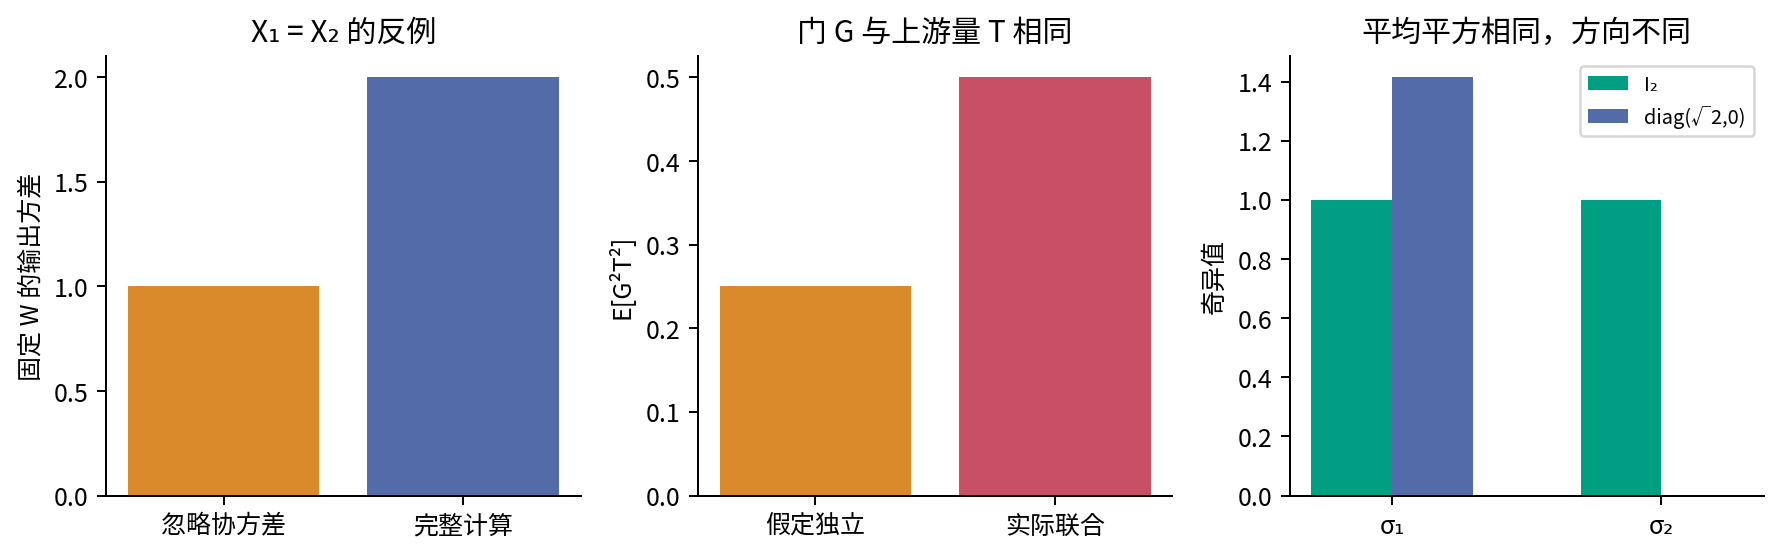

In [11]:
print(rerun['mechanisms']['correlated_input'])
print(rerun['mechanisms']['gate_dependence'])
print(rerun['mechanisms']['jacobian_counterexample'])
display(Image(filename=str(BASE/'figures/11_assumption_failures.png')))

## 11 框架布局和零点约定
比较同一随机数生成器下的He初始化与显式公式，然后实际观察ReLU在0处的反向。

In [12]:
w=torch.empty(64,16,dtype=torch.float64)
torch.nn.init.kaiming_normal_(w,mode='fan_in',nonlinearity='relu',generator=torch.Generator().manual_seed(4))
expected=torch.randn(64,16,dtype=torch.float64,generator=torch.Generator().manual_seed(4))*math.sqrt(2/16)
print('He implementation maximum absolute difference:',float(torch.max(torch.abs(w-expected))))
z=torch.tensor([-1.,0.,1.],dtype=torch.float64,requires_grad=True)
print('ReLU backward:',torch.autograd.grad(torch.relu(z).sum(),z)[0].tolist())
print('central difference at zero:',(max(0,1e-6)-max(0,-1e-6))/(2e-6))

He implementation maximum absolute difference: 0.0
ReLU backward: [0.0, 0.0, 1.0]
central difference at zero: 0.5


## 12 契约测试与失效保护
测试必须实际执行，不能只导入测试模块。输入校验在-O模式下也应保留。

In [13]:
import test_experiment
suite=unittest.defaultTestLoader.loadTestsFromModule(test_experiment)
result=unittest.TextTestRunner(verbosity=1).run(suite)
if not result.wasSuccessful():
    raise RuntimeError('测试失败')
print('executed tests:',result.testsRun)

.

.

.

.

.

...

.

.

.

----------------------------------------------------------------------
Ran 18 tests in 12.573s

OK


executed tests: 18


## 13 形成有限结论
从前向、探针、任务梯度和训练曲线各挑一个可重算数值。指出mean不为0、门相关性、有限宽共享和训练后依赖。这里没有测试集、真实任务排名、GPU或大型模型保证。

In [14]:
print('Complete: 48 training configurations, 576 initialization layer rows, 48 width-study rows.')
print('Scope: synthetic training mechanisms; no external generalization estimate.')
print('Write your own conclusion before reading answers.md section 7.')

Complete: 48 training configurations, 576 initialization layer rows, 48 width-study rows.
Scope: synthetic training mechanisms; no external generalization estimate.
Write your own conclusion before reading answers.md section 7.
